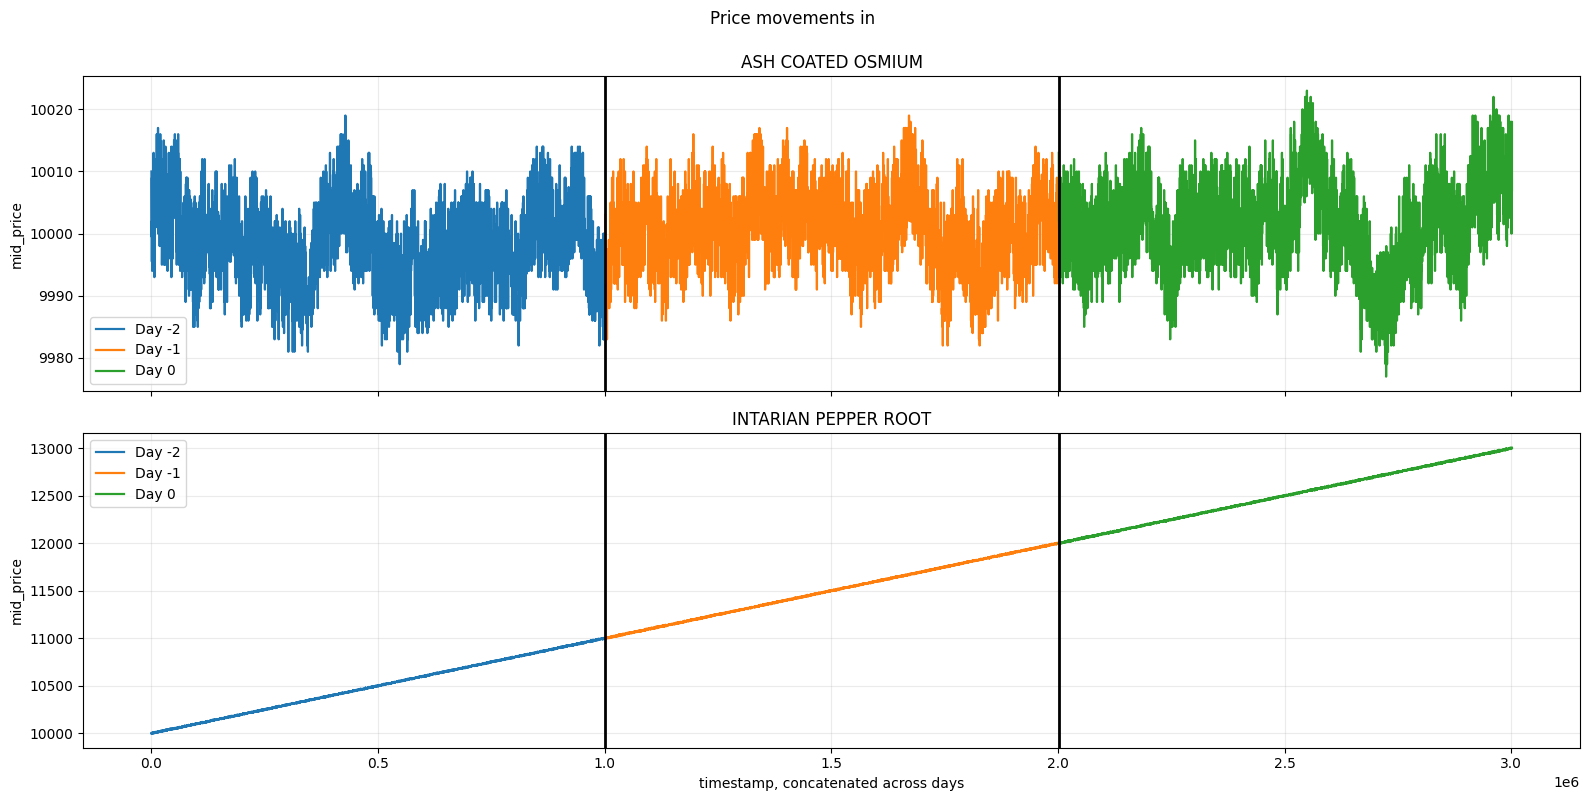

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 1
ROUND_FOLDER = Path(".")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

LEVELS = (1, 2, 3)


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    notebook_dir = Path.cwd()
    for root in (notebook_dir, notebook_dir.parent):
        candidate = root / path
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find data file: {path}")


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


In [3]:
# Distribution of raw alt_mid_price changes from one tick to the next + autocorrelation.
asset = "ASH_COATED_OSMIUM"
prices_csv = "prices_round_1_day_-1.csv"

sub = load_prices(prices_csv)
sub = (
    sub[sub["product"] == asset]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Drop the very first tick before constructing alt_mid_price-derived diagnostics.
sub = sub.iloc[1:].reset_index(drop=True)


def reconstruct_side_levels(frame: pd.DataFrame, side: str) -> pd.DataFrame:
    value_cols = [
        col
        for col in [f"{side}_price_1", f"{side}_price_2", f"{side}_price_3"]
        if col in frame.columns
    ]

    far_values: list[float | None] = []
    mid_values: list[float | None] = []
    far_state: float | None = None
    mid_state: float | None = None

    for _, row in frame.iterrows():
        values = []
        for col in value_cols:
            value = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(value) and value > 0:
                values.append(float(value))

        values.sort()

        far_value = far_state
        mid_value = mid_state

        if values:
            pair_found = False

            if side == "ask" and len(values) >= 2:
                candidate_mid = values[-2]
                candidate_far = values[-1]
                if candidate_far - candidate_mid <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True
            elif side == "bid" and len(values) >= 2:
                candidate_far = values[0]
                candidate_mid = values[1]
                if candidate_mid - candidate_far <= 3:
                    far_value = candidate_far
                    mid_value = candidate_mid
                    pair_found = True

            if not pair_found:
                candidate = values[-1] if side == "ask" else values[0]

                if far_state is None or mid_state is None:
                    far_value = candidate
                    mid_value = candidate
                elif abs(candidate - far_state) <= 1:
                    far_value = candidate
                elif abs(candidate - mid_state) <= 1:
                    mid_value = candidate

        far_state = far_value
        mid_state = mid_value
        far_values.append(far_value)
        mid_values.append(mid_value)

    return pd.DataFrame({f"far_{side}": far_values, f"mid_{side}": mid_values})


bid_levels = reconstruct_side_levels(sub, "bid")
ask_levels = reconstruct_side_levels(sub, "ask")
sub = pd.concat([sub, bid_levels, ask_levels], axis=1)
sub["alt_mid_price"] = sub[["far_bid", "mid_bid", "far_ask", "mid_ask"]].mean(axis=1)

raw_change = sub["alt_mid_price"].diff().dropna()



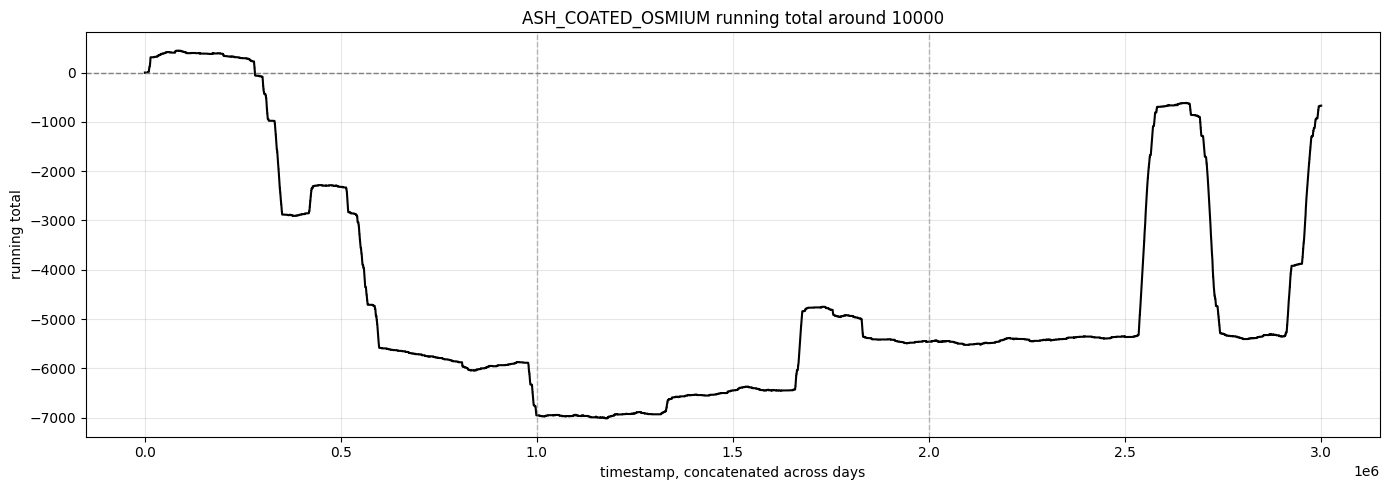

In [4]:
# Running total for ASH_COATED_OSMIUM across all round-1 days.
asset = "ASH_COATED_OSMIUM"

asset_frames = []
for prices_csv in PRICE_FILES:
    day_df = load_prices(prices_csv.name if hasattr(prices_csv, "name") else str(prices_csv))
    day_df = (
        day_df[day_df["product"] == asset]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )
    if day_df.empty:
        continue

    asset_frames.append(
        day_df[["day", "timestamp", "bid_price_1", "bid_volume_1", "ask_price_1", "ask_volume_1"]]
    )

if not asset_frames:
    raise ValueError(f"No data found for {asset} in the round-1 price files")

sub = pd.concat(asset_frames, ignore_index=True)
sub["timestamp"] = pd.to_numeric(sub["timestamp"], errors="coerce")
sub = sub.dropna(subset=["timestamp"]).sort_values(["day", "timestamp"]).reset_index(drop=True)

best_bid = pd.to_numeric(sub["bid_price_1"], errors="coerce")
best_bid_qty = pd.to_numeric(sub["bid_volume_1"], errors="coerce").fillna(0)
best_ask = pd.to_numeric(sub["ask_price_1"], errors="coerce")
best_ask_qty = pd.to_numeric(sub["ask_volume_1"], errors="coerce").fillna(0)

running_change = pd.Series(0.0, index=sub.index)
running_change = running_change + best_bid_qty.where(best_bid > 10000, 0)
running_change = running_change - best_ask_qty.where(best_ask < 10000, 0)
sub["running_total"] = running_change.cumsum()

# Put the days on one continuous x-axis with visible gaps so day 0 is visible.
gap = 1000.0
day_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_rows = sub[sub["day"] == day]
    max_timestamp = float(day_rows["timestamp"].max()) if not day_rows.empty else 0.0
    day_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

sub["x"] = sub["timestamp"] + sub["day"].map(day_offsets)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sub["x"], sub["running_total"], color="black", linewidth=1.5)
for separator in separator_positions[:-1]:
    ax.axvline(separator, color="grey", linewidth=1, linestyle="--", alpha=0.5)
ax.axhline(0, color="grey", linewidth=1, linestyle="--")
ax.set_title("ASH_COATED_OSMIUM running total around 10000")
ax.set_xlabel("timestamp, concatenated across days")
ax.set_ylabel("running total")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
